In [17]:
import torchvision
import torch
from PIL import Image

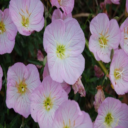

In [18]:
# create a vector of zeros of size 5

size = (128,128)
transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size), torchvision.transforms.ToTensor()])
train_dataset = list(torchvision.datasets.Flowers102("./flowers", "train", transform=transform, download=True))
test_dataset = list(torchvision.datasets.Flowers102("./flowers", "test", transform=transform, download=True))


def visualize_image(img:torch.Tensor) -> Image.Image:
    return Image.fromarray((img.permute(1, 2, 0) * 255).to(torch.uint8).numpy())


visualize_image(train_dataset[0][0])

In [19]:
len(train_dataset)

1020

In [20]:
train_dataset[0]

(tensor([[[0.0471, 0.0706, 0.0745,  ..., 0.1255, 0.4667, 0.5647],
          [0.0667, 0.0667, 0.0549,  ..., 0.1333, 0.4824, 0.5647],
          [0.0824, 0.0745, 0.0549,  ..., 0.1451, 0.5059, 0.5686],
          ...,
          [0.1059, 0.1059, 0.0863,  ..., 0.5020, 0.4902, 0.4706],
          [0.1137, 0.1137, 0.1294,  ..., 0.5059, 0.4784, 0.4706],
          [0.1020, 0.1176, 0.1176,  ..., 0.5020, 0.4745, 0.4667]],
 
         [[0.0863, 0.1255, 0.1373,  ..., 0.1294, 0.3412, 0.3961],
          [0.0941, 0.1098, 0.1059,  ..., 0.1294, 0.3490, 0.3922],
          [0.0941, 0.0941, 0.0824,  ..., 0.1294, 0.3608, 0.3843],
          ...,
          [0.2000, 0.1804, 0.1333,  ..., 0.4235, 0.4118, 0.3922],
          [0.2118, 0.2039, 0.2000,  ..., 0.4275, 0.4039, 0.3922],
          [0.2078, 0.2196, 0.2196,  ..., 0.4196, 0.4078, 0.3765]],
 
         [[0.0314, 0.0392, 0.0353,  ..., 0.0863, 0.4745, 0.5961],
          [0.0392, 0.0353, 0.0235,  ..., 0.0980, 0.4902, 0.5922],
          [0.0431, 0.0353, 0.0235,  ...,

first value = pixal val of img

second value = 0-101, classification of flower

In [21]:
import matplotlib.pyplot as plt 

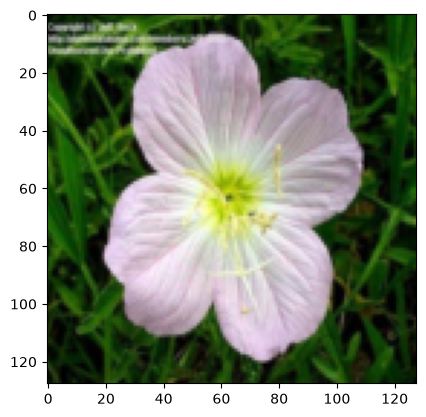

In [22]:
plt.imshow(visualize_image(train_dataset[1][0]))

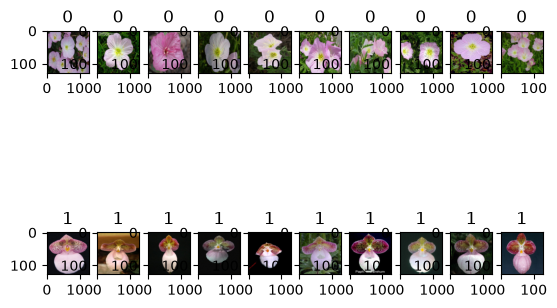

In [23]:
f, ax = plt.subplots(2, 10)

for i, (im, l) in enumerate(list(train_dataset)[:20]):
    ax[i // 10, i % 10].imshow(visualize_image(im))
    ax[i // 10, i % 10].set_title(l)


class_0 = list(train_dataset)[:10]
class_1 = list(train_dataset)[10:20]
 

## Nearest Neighbor Classifier

f: R -> {0, 1}

- input x
- **Find closest data point in dataset**
- Return its label l

In [24]:
class_01 = list(train_dataset)[:20]

def nn_classifier(x):
    # find distance between new data element with entire dataset and return min dist label
    dist = [((x - im).pow(2).sum(), l) for im, l in class_01]
    return min(dist)[1] # 1 returns label, 0 returns img pix val

nn_classifier(test_dataset[0][0])

accuracy = sum(nn_classifier(x) == l for x, l in list(test_dataset)[:20]) / 20
print(accuracy)

0.4


## K Nearest Neighbor Classifier

f: R -> {0, 1}

- Input x
- Find k closest data points in dataset
- **Return most common label**

In [44]:
class_01 = list(train_dataset)[:20]

def knn_classifier(x, k=3):
    # find distance between new data element with entire dataset and return k closest label
    dist = [((x - im).pow(2).sum(), l) for im, l in class_01]

    k_closest = [l for _, l in sorted(dist)[:k]]
    
    return sorted(k_closest)[k // 2] # return median since theres only 2 classes

knn_classifier(test_dataset[3][0])

accuracy = sum(knn_classifier(x) == l for x, l in list(test_dataset)[:20]) / 20
print(accuracy)

0.5


If you have n classes then youll have to do some function calls

If you have two classes, you find median

## K Nearest Neighbor Regression

f: R -> R
- Input x
- Find k closest data points in dataset
- **Returb avg value**

NOTE:

- pixel distances between images are terriblee metrics to figure out if two things are the same thing

In [55]:
class_01 = list(train_dataset)[:20]

def knn_regression(x, k=3):
    # find distance between new data element with entire dataset and return k closest label
    dist = [((x - im).pow(2).sum(), l) for im, l in class_01]

    k_closest = [l for _, l in sorted(dist)[:k]]
    
    return torch.mean(torch.tensor(k_closest).float()) # return avg (mean) value

knn_regression(test_dataset[3][0])

# accuracy = sum(knn_regressor(x) == l for x, l in list(test_dataset)[:20]) / 20
# print(accuracy)

tensor(0.6667)